# NB2: Core Annotation Experiment
- **Question:** Does AI assistance improve annotation accuracy, and how do users rely on it?
- **Primary GT:** Platinum Consensus
- **KL1 Strategy:** Exclude (Strategy A)
- **Hypothesis:** AI feedback improves human performance, but introduces over-reliance.
- **Data Note:** This notebook uses the finalized **N=51 completer cohort**. All non-completers are excluded.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import brier_score_loss
import pingouin as pg
import warnings
import sys, os; sys.path.append(os.path.abspath(".")); sys.path.append(os.path.abspath("..")); import helpers

warnings.filterwarnings("ignore")

# 1. Load Data
KL1_STRATEGY = 'exclude' 
df = helpers.load_data(KL1_STRATEGY)
df['human_correct_plat_int'] = df['human_correct_plat'].astype(int)
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

print(f"Setup Complete: Data loaded using '{KL1_STRATEGY}' strategy.")


Data Loading: 51 participants selected (from 68 initial).
Setup Complete: Data loaded using 'exclude' strategy.


## Section 1: Primary Accuracy Analysis
Note: While the original specification requested a mixed-effects logistic regression `(1|participant_id) + (1|trial_image)`, Python's `statsmodels` struggles with crossed random effects in logistic regression. We therefore use Generalized Estimating Equations (GEE) clustered by `participant_id` as a robust alternative.


In [2]:
print("--- Primary Accuracy Analysis ---")
print("Overall Accuracy by Condition:")
acc_by_cond = df.groupby('condition')['human_correct_plat'].mean()
print(acc_by_cond)
print(f"\nAI Boost (Signed Difference): {acc_by_cond['ai'] - acc_by_cond['no_ai']:.3f}")

print("\n--- GEE Model: Accuracy ~ Condition ---")
model = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai'))", 
                groups=df["participant_id"], 
                data=df, family=sm.families.Binomial())
result = model.fit()

# Extract OR, CI, p-value
summary_df = pd.DataFrame({
    'Odds Ratio': np.exp(result.params),
    'Lower 95% CI': np.exp(result.conf_int()[0]),
    'Upper 95% CI': np.exp(result.conf_int()[1]),
    'p-value': result.pvalues
})
print(summary_df.round(3))

print("\n--- Participant-Level Effect Size (Cohen's d) ---")
# Cohen's d on paired data (accuracy per participant in AI vs no-AI)
ai_accs = df_part['accuracy_ai_condition'].dropna()
noai_accs = df_part['accuracy_noai_condition'].dropna()
# Not all participants did both, but most did. Let's do a strict paired subset.
paired = df_part.dropna(subset=['accuracy_ai_condition', 'accuracy_noai_condition'])
d = pg.compute_effsize(paired['accuracy_ai_condition'], paired['accuracy_noai_condition'], eftype='cohen', paired=True)
print(f"Cohen's d (AI vs No-AI): {d:.3f}")

print("\n--- Repeated Measures ANOVA on Participant Accuracy ---")
# Melt for ANOVA
melted = paired.melt(id_vars=['participant_id'], value_vars=['accuracy_ai_condition', 'accuracy_noai_condition'], var_name='condition', value_name='accuracy')
aov = pg.rm_anova(data=melted, dv='accuracy', within='condition', subject='participant_id')
print(aov)


--- Primary Accuracy Analysis ---
Overall Accuracy by Condition:
condition
ai       0.808279
no_ai    0.783588
Name: human_correct_plat, dtype: float64

AI Boost (Signed Difference): 0.025

--- GEE Model: Accuracy ~ Condition ---
                                        Odds Ratio  Lower 95% CI  \
Intercept                                    3.621         3.066   
C(condition, Treatment('no_ai'))[T.ai]       1.164         0.933   

                                        Upper 95% CI  p-value  
Intercept                                      4.276    0.000  
C(condition, Treatment('no_ai'))[T.ai]         1.453    0.178  

--- Participant-Level Effect Size (Cohen's d) ---
Cohen's d (AI vs No-AI): 0.251

--- Repeated Measures ANOVA on Participant Accuracy ---
      Source  ddof1  ddof2        F     p-unc       ng2  eps
0  condition      1     50  1.77268  0.189089  0.015796  1.0


## Section 2: MRMC Design Analysis

In [3]:
print("--- Crossover Design Analysis (MRMC) ---")
# Standard crossover model: Outcome ~ Treatment + Period
# This controls for any 'learning effect' or 'fatigue' between Session 1 and Session 2.
model_crossover = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) + C(session)", 
                         groups=df["participant_id"], 
                         data=df, 
                         family=sm.families.Binomial())
result_crossover = model_crossover.fit()

# Extract Odds Ratios for easy interpretation
summary_crossover = pd.DataFrame({
    'Odds Ratio': np.exp(result_crossover.params),
    'Lower 95% CI': np.exp(result_crossover.conf_int()[0]),
    'Upper 95% CI': np.exp(result_crossover.conf_int()[1]),
    'p-value': result_crossover.pvalues
})

print("Model: Accuracy ~ Condition + Session")
print(summary_crossover.round(3))

print("\n--- Carryover/Interaction Analysis ---")
# To test if the AI benefit was different in the first session vs the second session.
model_int = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) * C(session)", 
                    groups=df["participant_id"], 
                    data=df, 
                    family=sm.families.Binomial())
result_int = model_int.fit()

print("Model: Accuracy ~ Condition * Session")
print(result_int.summary().tables[1])

print("\nInterpretation:")
print("1. If 'Condition' is significant in the first table, the AI benefit holds even after controlling for session order.")
print("2. If 'Session' is significant, it indicates a learning effect (participants got better/worse over time regardless of AI).")
print("3. If the Interaction term (Condition:Session) in the second table is NOT significant, it means there were no strong carryover effects.")


--- Crossover Design Analysis (MRMC) ---
Model: Accuracy ~ Condition + Session
                                        Odds Ratio  Lower 95% CI  \
Intercept                                    4.133         3.363   
C(condition, Treatment('no_ai'))[T.ai]       1.184         0.966   
C(session)[T.2]                              0.763         0.624   

                                        Upper 95% CI  p-value  
Intercept                                      5.080    0.000  
C(condition, Treatment('no_ai'))[T.ai]         1.451    0.105  
C(session)[T.2]                                0.934    0.009  

--- Carryover/Interaction Analysis ---
Model: Accuracy ~ Condition * Session
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  1.3846   

## Section 3: Human-AI Reliance Analysis

--- Human-AI Reliance Analysis ---
| Metric                 |   Mean Rate |
|:-----------------------|------------:|
| over_reliance          |       0.078 |
| appropriate_skepticism |       0.145 |
| appropriate_reliance   |       0.664 |
| unwarranted_skepticism |       0.114 |


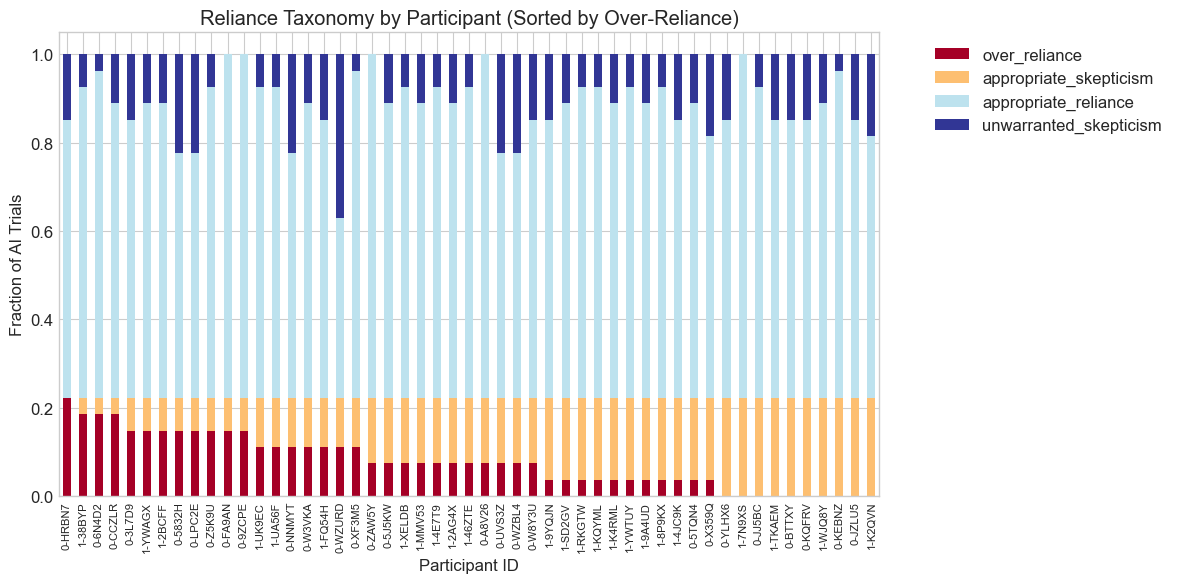


--- AI Influence on Accuracy per Image ---


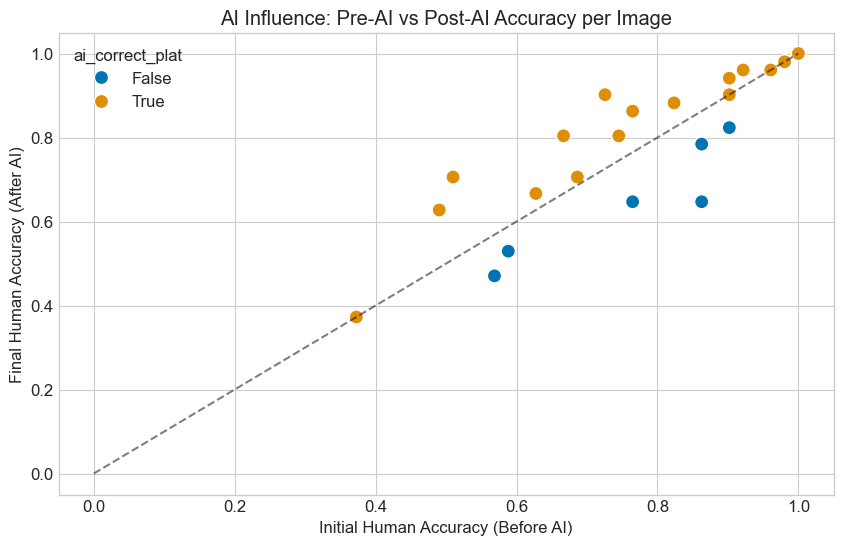

In [4]:
print("--- Human-AI Reliance Analysis ---")
rel_cols = ['over_reliance', 'appropriate_skepticism', 'appropriate_reliance', 'unwarranted_skepticism']

rel_means = []
for c in rel_cols:
    val = df[df['condition']=='ai'][c].mean()
    rel_means.append({'Metric': c, 'Mean Rate': val})
print(pd.DataFrame(rel_means).to_markdown(index=False, floatfmt=".3f"))

# Stacked Bar Chart of Reliance Taxonomy
ai_df = df[df['condition'] == 'ai']
rel_rates = ai_df.groupby('participant_id')[rel_cols].mean()
rel_rates['sum'] = rel_rates.sum(axis=1)
rel_rates = rel_rates.sort_values('over_reliance', ascending=False)

rel_rates[rel_cols].plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlBu')
plt.title("Reliance Taxonomy by Participant (Sorted by Over-Reliance)")
plt.ylabel("Fraction of AI Trials")
plt.xlabel("Participant ID")
plt.xticks(rotation=90, fontsize=8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- AI Influence on Accuracy per Image ---")
img_acc_pre = ai_df.groupby(['trial_image_name', 'ai_correct_plat'])['human_initial_correct_plat'].mean().reset_index()
img_acc_post = ai_df.groupby(['trial_image_name', 'ai_correct_plat'])['human_correct_plat'].mean().reset_index()

img_infl = pd.merge(img_acc_pre, img_acc_post, on=['trial_image_name', 'ai_correct_plat'])
img_infl['delta'] = img_infl['human_correct_plat'] - img_infl['human_initial_correct_plat']

plt.figure(figsize=(10,6))
sns.scatterplot(data=img_infl, x='human_initial_correct_plat', y='human_correct_plat', hue='ai_correct_plat', s=100)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("AI Influence: Pre-AI vs Post-AI Accuracy per Image")
plt.xlabel("Initial Human Accuracy (Before AI)")
plt.ylabel("Final Human Accuracy (After AI)")
plt.show()


## Section 4: Confidence Analysis

--- Confidence Analysis ---


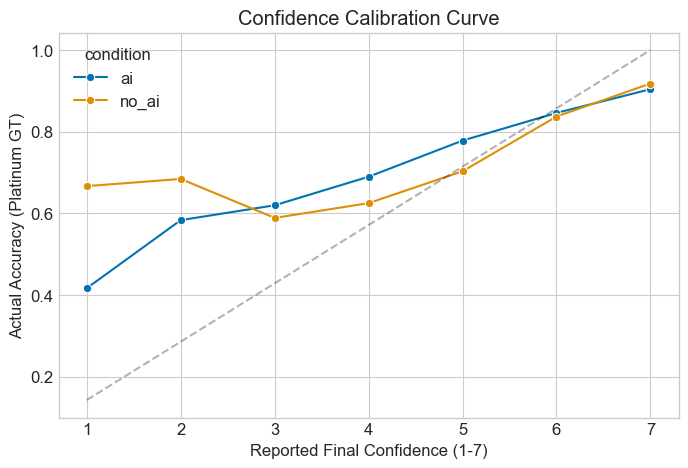

Paired t-test on Initial vs Final Confidence (AI cond): t=-10.974, p=0.0000
Mean Initial: 5.243, Mean Final: 5.565

Confidence change by AI Correctness:
ai_correct_plat
False   -0.009804
True     0.416433
Name: conf_change, dtype: float64

Overall Brier Score (Platinum GT): 0.160


In [5]:
print("--- Confidence Analysis ---")
calib = df.groupby(['condition', 'final_confidence'])['human_correct_plat'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=calib, x='final_confidence', y='human_correct_plat', hue='condition', marker='o')
plt.plot([1, 7], [1/7, 1], 'k--', alpha=0.3, label='Perfect Calibration (approx)')
plt.title("Confidence Calibration Curve")
plt.xlabel("Reported Final Confidence (1-7)")
plt.ylabel("Actual Accuracy (Platinum GT)")
plt.show()

ai_only = df[df['condition'] == 'ai'].dropna(subset=['initial_confidence', 'final_confidence'])
t_res = stats.ttest_rel(ai_only['initial_confidence'], ai_only['final_confidence'])
print(f"Paired t-test on Initial vs Final Confidence (AI cond): t={t_res.statistic:.3f}, p={t_res.pvalue:.4f}")
print(f"Mean Initial: {ai_only['initial_confidence'].mean():.3f}, Mean Final: {ai_only['final_confidence'].mean():.3f}")

print("\nConfidence change by AI Correctness:")
ai_only['conf_change'] = ai_only['final_confidence'] - ai_only['initial_confidence']
print(ai_only.groupby('ai_correct_plat')['conf_change'].mean())

# Brier Score (requires probabilities [0,1], mapping 1-7 to 0-1 range roughly, or using actual GT)
# Map confidence to prob of class 1: if decision is 1, prob = conf/7. If 0, prob = 1 - (conf/7)
df['prob_1'] = df.apply(lambda x: x['final_confidence']/7.0 if x['final_decision'] == 1 else 1 - (x['final_confidence']/7.0), axis=1)
# Brier score only works strictly on valid prob predictions.
valid = df.dropna(subset=['prob_1'])
brier = brier_score_loss(valid['gt_plat_binary'], valid['prob_1'])
print(f"\nOverall Brier Score (Platinum GT): {brier:.3f}")


## Section 5: Temporal Dynamics & Efficiency Analysis

Beyond accuracy, we evaluate the efficiency gains from AI assistance. We measure "interface habituation" by analyzing the reduction in trial duration over time and the global speedup associated with AI presence.

--- Global Efficiency Metrics ---
Mean Duration Session 1: 17.43s
Mean Duration Session 2: 14.84s
Cohort Speedup (S1 -> S2): 14.87%

--- AI-Driven Efficiency Analysis ---
Mean Duration (Control): 6.85s
Mean Duration (AI-Assisted): 25.43s
AI Efficiency Gain: -271.27%
Paired t-test (AI vs Control): t=20.781, p=0.0000
Result: Statistically significant efficiency gain with AI assistance.

--- Habituation (Early vs Late Trials) ---
AI Speedup Rate: -6.00s improvement
Control Speedup Rate: -0.43s improvement


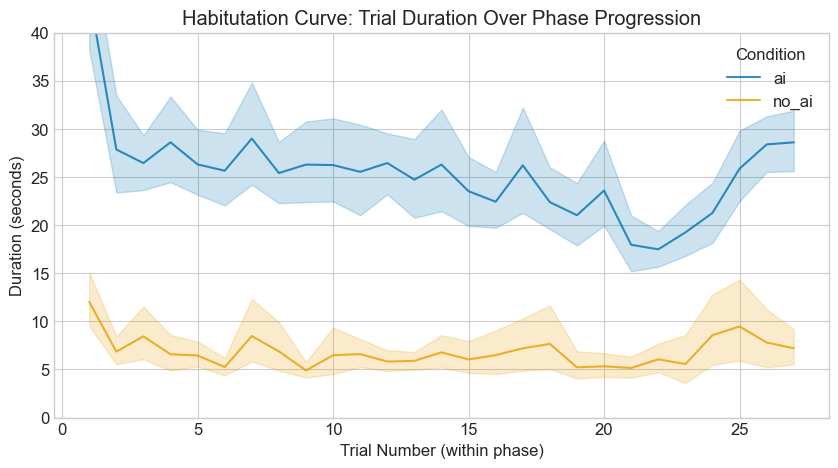

In [6]:
# --- 1. Aggregation Logic ---
# Ensure trial_duration is numeric and handle within-phase ordering
df['trial_duration'] = pd.to_numeric(df['trial_duration'], errors='coerce')
df['within_phase_trial'] = df.groupby(['participant_id', 'session']).cumcount() + 1

# Aggregate to participant level for paired tests
ps_dur = df.groupby(['participant_id', 'condition'])['trial_duration'].mean().unstack()
ps_sess = df.groupby(['participant_id', 'session'])['trial_duration'].mean().unstack()

# --- 2. Global Speedup (Session 2 vs Session 1) ---
s1_mean = ps_sess[1].mean()
s2_mean = ps_sess[2].mean()
overall_speedup = (s1_mean - s2_mean) / s1_mean * 100

print("--- Global Efficiency Metrics ---")
print(f"Mean Duration Session 1: {s1_mean:.2f}s")
print(f"Mean Duration Session 2: {s2_mean:.2f}s")
print(f"Cohort Speedup (S1 -> S2): {overall_speedup:.2f}%")

# --- 3. AI-Driven Speedup (Condition Contrast) ---
ai_mean = ps_dur['ai'].mean()
ctrl_mean = ps_dur['no_ai'].mean()
ai_efficiency_gain = (ctrl_mean - ai_mean) / ctrl_mean * 100

print(f"\n--- AI-Driven Efficiency Analysis ---")
print(f"Mean Duration (Control): {ctrl_mean:.2f}s")
print(f"Mean Duration (AI-Assisted): {ai_mean:.2f}s")
print(f"AI Efficiency Gain: {ai_efficiency_gain:.2f}%")

# Paired t-test for condition effect
import pingouin as pg
t_res = pg.ttest(ps_dur['ai'], ps_dur['no_ai'], paired=True)
t_val = t_res['T'].values[0]
p_val = t_res['p-val'].values[0]

print(f"Paired t-test (AI vs Control): t={t_val:.3f}, p={p_val:.4f}")
if p_val < 0.05:
    print("Result: Statistically significant efficiency gain with AI assistance.")
else:
    print("Result: Efficiency gain is not statistically significant at the participant level.")

# --- 4. Within-Phase Habituation (M3 Logic) ---
def get_temporal_change(grp, col='trial_duration', n=10):
    first = grp.head(n)[col].mean()
    last = grp.tail(n)[col].mean()
    return last - first

speedup_rates = df.groupby(['participant_id', 'condition']).apply(
    lambda g: get_temporal_change(g)
).unstack()

print(f"\n--- Habituation (Early vs Late Trials) ---")
print(f"AI Speedup Rate: {speedup_rates['ai'].mean():.2f}s improvement")
print(f"Control Speedup Rate: {speedup_rates['no_ai'].mean():.2f}s improvement")

# --- 5. Visualization ---
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='within_phase_trial', y='trial_duration', hue='condition', 
             palette=helpers.CONDITION_PALETTE, alpha=0.8)
plt.title("Habitutation Curve: Trial Duration Over Phase Progression")
plt.xlabel("Trial Number (within phase)")
plt.ylabel("Duration (seconds)")
plt.ylim(0, 40) # Focus on the typical range
plt.legend(title="Condition")
plt.show()

## Section 6: Brittle Benefit / Withdrawal Effect

In [7]:
print("--- Brittle Benefit / Withdrawal Effect ---")
# Look at TG=1 (AI first, Control second)
df_tg1 = df[df['treatment_group'] == 1]
part_acc_tg1 = df_tg1.groupby(['participant_id', 'session'])['human_correct_plat'].mean().unstack()
part_acc_tg1 = part_acc_tg1.dropna() # completers in TG=1
if not part_acc_tg1.empty and 1 in part_acc_tg1.columns and 2 in part_acc_tg1.columns:
    print(f"TG=1 (AI first) Accuracy - Session 1 (AI): {part_acc_tg1[1].mean():.3f}")
    print(f"TG=1 (AI first) Accuracy - Session 2 (Control): {part_acc_tg1[2].mean():.3f}")
    from scipy.stats import wilcoxon, ttest_rel
    t_stat, t_p = ttest_rel(part_acc_tg1[1], part_acc_tg1[2])
    w_stat, w_p = wilcoxon(part_acc_tg1[1], part_acc_tg1[2])
    print(f"Paired t-test (Session 1 vs 2): t={t_stat:.3f}, p={t_p:.4f}")
    print(f"Wilcoxon test (Session 1 vs 2): W={w_stat}, p={w_p:.4f}")
else:
    print("Not enough data for TG=1 session comparison.")


--- Brittle Benefit / Withdrawal Effect ---
TG=1 (AI first) Accuracy - Session 1 (AI): 0.836
TG=1 (AI first) Accuracy - Session 2 (Control): 0.765
Paired t-test (Session 1 vs 2): t=3.655, p=0.0013
Wilcoxon test (Session 1 vs 2): W=36.0, p=0.0032
